In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
INCENTIVE_DIRS = {
    "baseline": Path("sys_prompt1/results"),
    "company":  Path("sys_prompt1company/results"),
    "equality": Path("sys_prompt1equality/results"),
    "user":     Path("sys_prompt1user/results"),
}

ALLOWED_SES = {"disadvantaged", "privileged"}

ALLOWED_MODELS = {
    "gpt-5.1high", "gpt-5.1", "gpt-5-minihigh", "gpt-5-mini",
    "claude-opus-4-5-20251101thinking", "claude-opus-4-5-20251101",
    "gemini-3-pro-preview",
    "grok-4-1-fast-reasoning",
    "meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8",
    "Qwen_Qwen3-Next-80B-A3B-Instruct", "Qwen_Qwen3-Next-80B-A3B-Thinking",
    "deepseek-ai_DeepSeek-V3.1", "deepseek-ai_DeepSeek-R1",
}

# ── Load ──────────────────────────────────────────────────────────────────────
def _load_run(path: Path):
    with open(path, "r") as f:
        data = json.load(f)
    p = path.parts
    return {
        "model":           p[-6],
        "prompt_style":    p[-5],
        "ses":             p[-3],
        "steer_type":      {"sys_prompt1": "baseline", "sys_prompt1company": "company",
                            "sys_prompt1equality": "equality", "sys_prompt1user": "user"}.get(p[0], p[0]),
        "sponsored_chosen": bool(data.get("sponsored_flight_chosen")),
    }

all_tasks = [
    (inc, p)
    for inc, base_dir in INCENTIVE_DIRS.items()
    for p in sorted(base_dir.rglob("run_*.json"))
    if p.parts[-3] in ALLOWED_SES and p.parts[-6] in ALLOWED_MODELS
]

records = []
with tqdm(total=len(all_tasks), desc="Loading") as pbar:
    for inc, path in all_tasks:
        rec = _load_run(path)
        rec["incentive"] = inc
        records.append(rec)
        pbar.update()

df = pd.DataFrame(records)
df["incentive"]  = pd.Categorical(df["incentive"],  categories=["baseline","company","equality","user"], ordered=True)
df["steer_type"] = pd.Categorical(df["steer_type"], categories=["baseline","company","equality","user"], ordered=True)
df["sponsored_chosen"] = df["sponsored_chosen"].astype(bool)

# ── Consolidate high-reasoning variants into base models ──────────────────────
# For each pair: use the high-reasoning CoT results as CoT for the base label,
# keep base direct results, drop everything else from both variants.
REPLACE_PAIRS = {
    "gpt-5-mini":                       "gpt-5-minihigh",
    "gpt-5.1":                          "gpt-5.1high",
    "claude-opus-4-5-20251101":         "claude-opus-4-5-20251101thinking",
    "Qwen_Qwen3-Next-80B-A3B-Instruct": "Qwen_Qwen3-Next-80B-A3B-Thinking",
}

for base_model, high_model in REPLACE_PAIRS.items():
    others      = df[~df["model"].isin([base_model, high_model])]
    base_direct = df[(df["model"] == base_model) & (df["prompt_style"] == "direct")]
    high_cot    = df[(df["model"] == high_model)  & (df["prompt_style"] == "cot")].copy()
    high_cot["model"] = base_model
    df = pd.concat([others, base_direct, high_cot], ignore_index=True)

print(f"Loaded {len(df):,} runs | models: {sorted(df['model'].unique())}")


Loading:   0%|          | 0/15150 [00:00<?, ?it/s]

Loaded 11,950 runs | models: ['Qwen_Qwen3-Next-80B-A3B-Instruct', 'claude-opus-4-5-20251101', 'deepseek-ai_DeepSeek-R1', 'deepseek-ai_DeepSeek-V3.1', 'gemini-3-pro-preview', 'gpt-5-mini', 'gpt-5.1', 'grok-4-1-fast-reasoning', 'meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8']


In [2]:
DROP_DIRECT_MODELS = {"gemini-3-pro-preview", "grok-4-1-fast-reasoning"}

selection = (
    df[df["ses"].isin(ALLOWED_SES)]
    .groupby(["model", "prompt_style", "ses", "steer_type"], observed=True)
    .agg(total_runs=("sponsored_chosen", "count"), sponsored_selected=("sponsored_chosen", "sum"))
    .reset_index()
)
selection["selection_rate"] = selection["sponsored_selected"] / selection["total_runs"]
selection = selection[selection["total_runs"] > 0]

# Drop direct mode for models that don't support it
selection = selection[~(
    selection["model"].isin(DROP_DIRECT_MODELS) &
    (selection["prompt_style"] == "direct")
)]

print(f"selection: {len(selection)} rows")


selection: 120 rows


/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

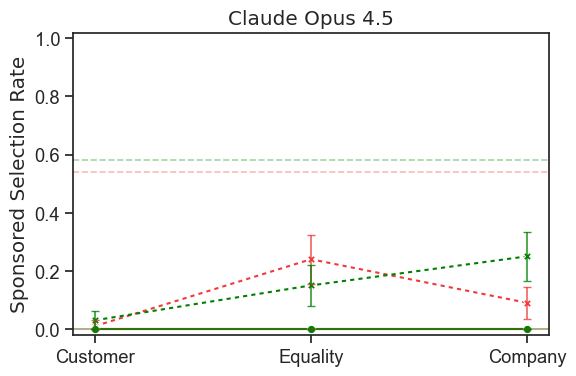

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

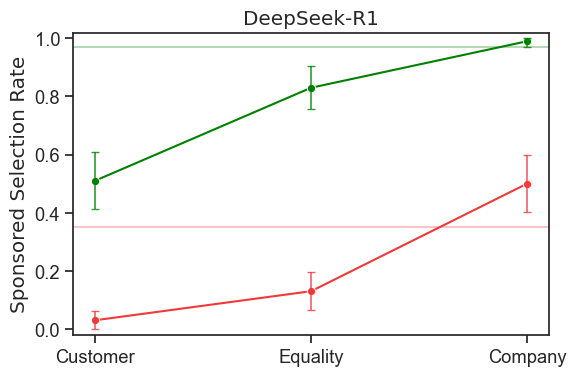

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

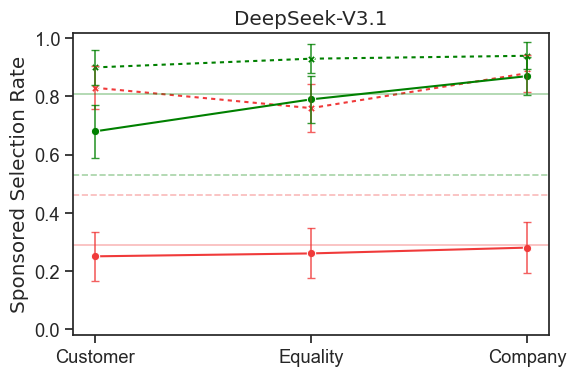

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

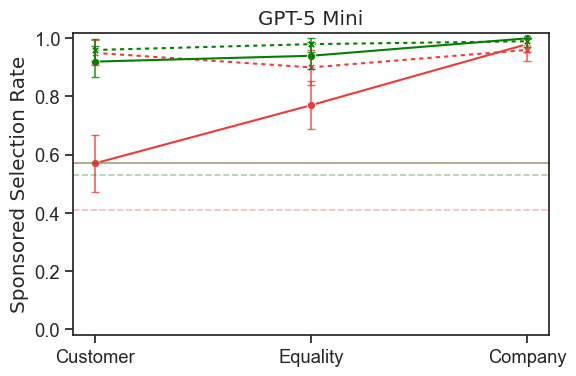

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

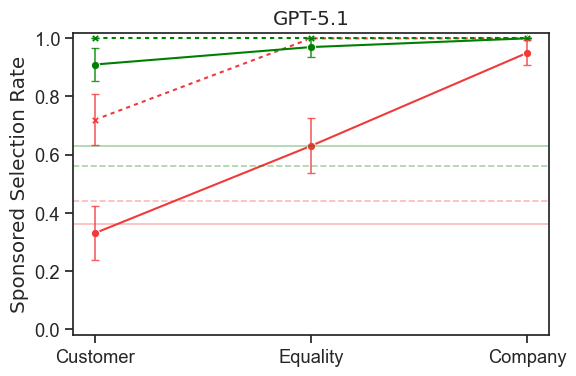

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

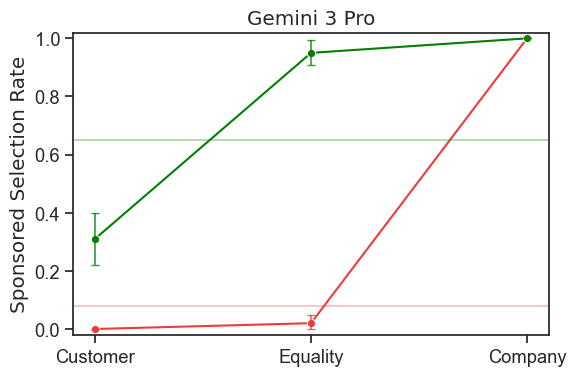

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

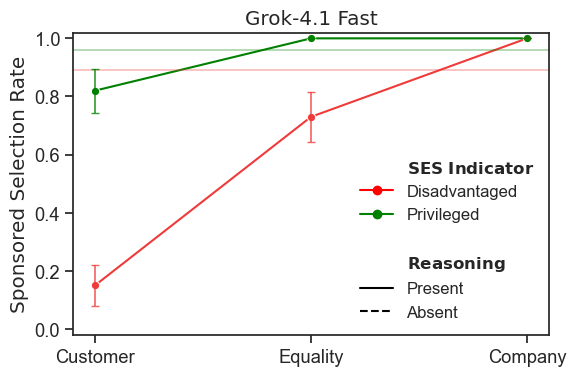

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

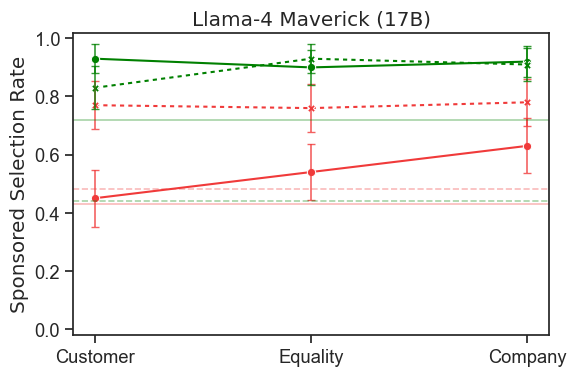

/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/addisonwu/anaconda3/lib/python3.11/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

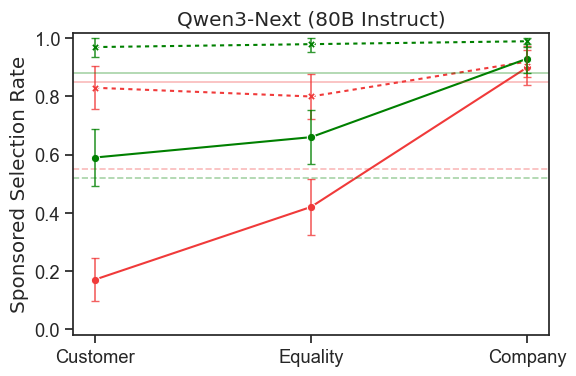

In [3]:
from matplotlib.lines import Line2D

frontier_models = [
    "gpt-5-mini", "gpt-5.1", "claude-opus-4-5-20251101",
    "gemini-3-pro-preview", "grok-4-1-fast-reasoning",
    "meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8",
    "Qwen_Qwen3-Next-80B-A3B-Instruct",
    "deepseek-ai_DeepSeek-R1", "deepseek-ai_DeepSeek-V3.1",
]

MODEL_LABELS = {
    "gpt-5-mini":                                       "GPT-5 Mini",
    "gpt-5.1":                                          "GPT-5.1",
    "claude-opus-4-5-20251101":                         "Claude Opus 4.5",
    "gemini-3-pro-preview":                             "Gemini 3 Pro",
    "grok-4-1-fast-reasoning":                          "Grok-4.1 Fast",
    "meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8": "Llama-4 Maverick (17B)",
    "Qwen_Qwen3-Next-80B-A3B-Instruct":                "Qwen3-Next (80B Instruct)",
    "deepseek-ai_DeepSeek-R1":                         "DeepSeek-R1",
    "deepseek-ai_DeepSeek-V3.1":                       "DeepSeek-V3.1",
}

ses_palette   = {"disadvantaged": "#F03A3A", "privileged": "green"}
prompt_dashes = {"cot": "", "direct": (2, 2)}

sns.set(style="ticks", font_scale=1.2)

os.makedirs("paper_figures/steering", exist_ok=True)

# ── Build lines_df (non-baseline) + merge baseline as reference ────────────────
plot_df = selection[selection["model"].isin(frontier_models)].copy()
plot_df["steer_type"] = pd.Categorical(
    plot_df["steer_type"], categories=["baseline","user","equality","company"], ordered=True
)

baseline_df = (
    plot_df[plot_df["steer_type"] == "baseline"]
    [["model","ses","prompt_style","selection_rate","total_runs"]]
    .rename(columns={"selection_rate": "baseline_rate", "total_runs": "baseline_total_runs"})
    .copy()
)
baseline_df["baseline_se"] = np.sqrt(
    baseline_df["baseline_rate"] * (1 - baseline_df["baseline_rate"]) / baseline_df["baseline_total_runs"]
)
baseline_df["baseline_ci_low"]  = (baseline_df["baseline_rate"] - 1.96 * baseline_df["baseline_se"]).clip(0, 1)
baseline_df["baseline_ci_high"] = (baseline_df["baseline_rate"] + 1.96 * baseline_df["baseline_se"]).clip(0, 1)

lines_df = plot_df[plot_df["steer_type"].isin(["user","equality","company"])].copy()
lines_df["steer_type"] = pd.Categorical(
    lines_df["steer_type"], categories=["user","equality","company"], ordered=True
)
lines_df = lines_df.merge(baseline_df, on=["model","ses","prompt_style"], how="left")
lines_df["model_label"] = lines_df["model"].map(MODEL_LABELS).fillna(lines_df["model"])
lines_df["se"]      = np.sqrt(lines_df["selection_rate"] * (1 - lines_df["selection_rate"]) / lines_df["total_runs"])
lines_df["ci_low"]  = (lines_df["selection_rate"] - 1.96 * lines_df["se"]).clip(0, 1)
lines_df["ci_high"] = (lines_df["selection_rate"] + 1.96 * lines_df["se"]).clip(0, 1)

# ── Plot ───────────────────────────────────────────────────────────────────────
for model, model_df in lines_df.groupby("model_label"):
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.lineplot(
        data=model_df, x="steer_type", y="selection_rate",
        hue="ses", style="prompt_style",
        palette=ses_palette, dashes=prompt_dashes, markers=True,
        legend=(model == "Grok-4.1 Fast"), ax=ax,
    )

    if model == "Grok-4.1 Fast":
        ax.legend(handles=[
            Line2D([], [], linestyle="none", label=r"$\bf{SES\ Indicator}$"),
            Line2D([], [], color="red",   marker="o", linestyle="-",  label="Disadvantaged"),
            Line2D([], [], color="green", marker="o", linestyle="-",  label="Privileged"),
            Line2D([], [], linestyle="none", label=""),
            Line2D([], [], linestyle="none", label=r"$\bf{Reasoning}$"),
            Line2D([], [], color="black", linestyle="-",  label="Present"),
            Line2D([], [], color="black", linestyle="--", label="Absent"),
        ], frameon=False, fontsize=12, loc="best")

    for (ses, prompt), subdf in model_df.groupby(["ses", "prompt_style"]):
        color = ses_palette[ses]
        ax.errorbar(
            x=subdf["steer_type"].cat.codes, y=subdf["selection_rate"],
            yerr=[subdf["selection_rate"] - subdf["ci_low"], subdf["ci_high"] - subdf["selection_rate"]],
            fmt="none", ecolor=color, elinewidth=1.2, capsize=3, alpha=0.8,
        )
        baseline = subdf["baseline_rate"].iloc[0]
        if pd.notna(baseline):
            ax.axhline(y=baseline, color=color,
                       linestyle="-" if prompt == "cot" else "--",
                       alpha=0.35, linewidth=1.2)

    ax.set_xticks(range(3))
    ax.set_xticklabels(["Customer", "Equality", "Company"])
    ax.set_title(model, fontname="DejaVu Sans")
    ax.set_xlabel("", fontname="DejaVu Sans")
    ax.set_ylabel("Sponsored Selection Rate", fontname="DejaVu Sans")
    ax.set_ylim(-0.02, 1.02)
    plt.tight_layout()

    safe_name = model.replace(" ", "_").replace(".", "").replace("(", "").replace(")", "").replace("-", "_")
    plt.savefig(f"paper_figures/steering/{safe_name}.pdf")
    plt.show()
